# OUTLIERS

* An outlier is a data point that significantly differs from the other data points in a sample.

* The outliers can be a result of a mistake during data collection or it can be just an indication of variance in data.

## Impact of an outlier

* Causes serious issues for statistical analysis.

* Skews the data.

* Significant impact on mean.

* Significant impact on standard deviation.

## Identify an outlier

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Graphs

In [12]:
#  In this data we have value 100,80,70,60,90 far distant from all other observation. other observations are between 10 to 15
data_1 = np.array([10,12,12,13,12,11,14,13,15,10,10, 10,
                   30,26,33,25,23 , -10, # outlier values
                   12, 14,13, 12,10, 10,11,12,15,12,13,12,11,14,13,15,10,15,12,10,14,13,15,10])

In [13]:
len(data_1)

42

## Using scatter plots
Using the scatter plot

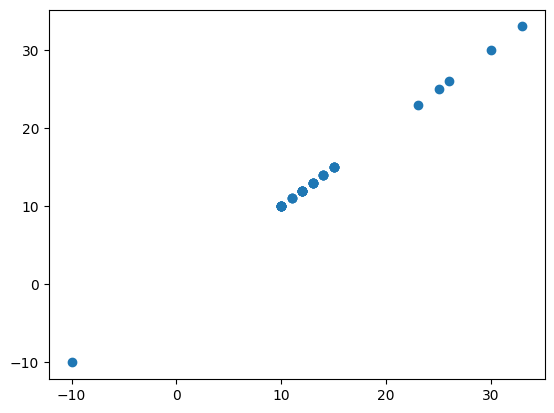

In [14]:
plt.scatter(data_1, data_1)

## Using BOX Plot

A box plot is a method for graphically depicting groups of numerical data through their quartiles. Box plots may also have lines extending vertically from the boxes (whiskers) indicating variability outside the upper and lower quartiles, hence the terms box-and-whisker plot and box-and-whisker diagram. Outliers may be plotted as individual points.

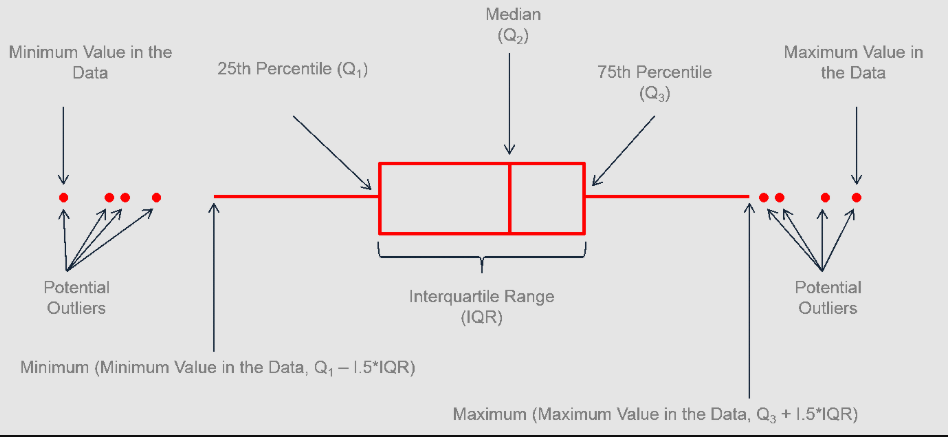

<Axes: >

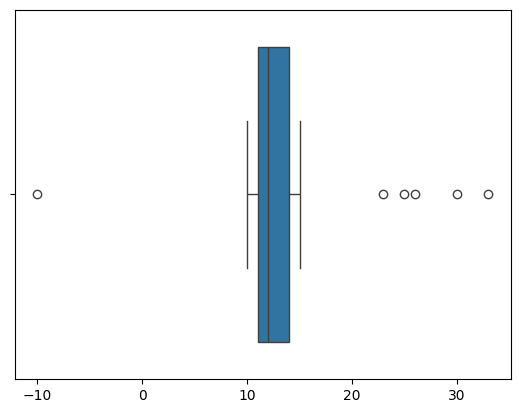

In [16]:
sns.boxplot(data_1, orient = 'h' )

## Violin Plots

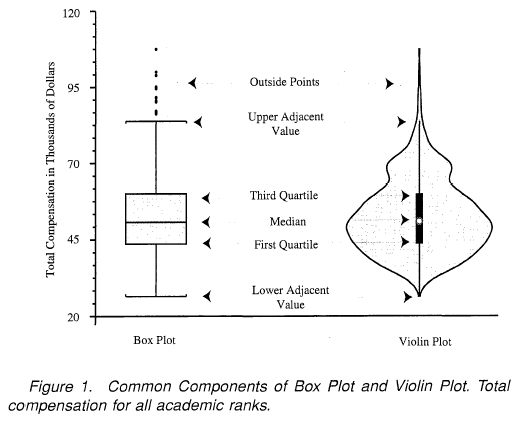

<Axes: >

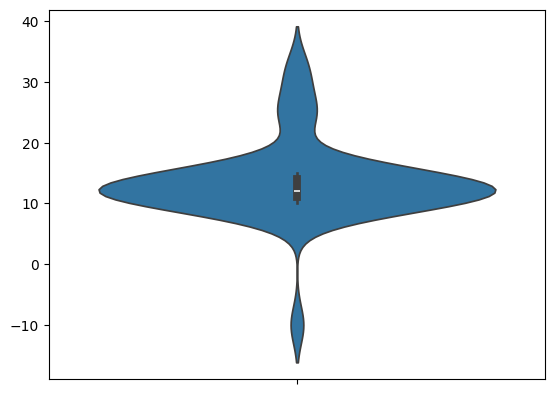

In [17]:
sns.violinplot(data_1)

### using eq

In [2]:
data1 = np.arange(50,53, 0.003)
len(data1)

1000

# Interquartile Range Method

- An outlier is any data point which is more than 1.5 times the interquartile range and is below the first quartile or above the third quartile.
- The IQR is calculated as the difference between the 75th and the 25th percentiles of the data and defines the box in a box and whisker plot.
- Box plot use the IQR method to display data and outliers(shape of the data) but in order to be get a list of identified outlier, we will need to use the mathematical formula and retrieve the outlier data.

### Making inner fences  by q1 -  ( 1 . 5 *  IQR )  and  q3 + ( 1 . 5 *  IQR )

- We mainly use the inner fences , so that we can keep the range small and even a minor outlier is removed.
- But sometimes the data has variance so it will be also removed which sometimes we don't desire . so we make a bigger range by making outer fences

In [18]:
data_1

array([ 10,  12,  12,  13,  12,  11,  14,  13,  15,  10,  10,  10,  30,
        26,  33,  25,  23, -10,  12,  14,  13,  12,  10,  10,  11,  12,
        15,  12,  13,  12,  11,  14,  13,  15,  10,  15,  12,  10,  14,
        13,  15,  10])

In [19]:
q1, q3 = np.percentile(data_1 , [25 , 75])

In [ ]:
q1 # 25th percentile

np.float64(11.0)

In [ ]:
q3 # 75th percentile

np.float64(14.0)

In [22]:
print(np.array(data_1))

[ 10  12  12  13  12  11  14  13  15  10  10  10  30  26  33  25  23 -10
  12  14  13  12  10  10  11  12  15  12  13  12  11  14  13  15  10  15
  12  10  14  13  15  10]


In [23]:
iqr = q3 - q1
iqr

np.float64(3.0)

In [24]:
lower_inner_fence = q1 - (1.5 * iqr)
upper_inner_fence = q3 + (1.5 * iqr)

In [25]:
lower_inner_fence

np.float64(6.5)

In [26]:
upper_inner_fence

np.float64(18.5)

In [30]:
# identify outliers
outliers = [x for x in data_1 if (x < lower_inner_fence) or (x > upper_inner_fence)]
print(np.array(outliers))

[ 30  26  33  25  23 -10]


In [31]:
outliers = []
for x in data_1:
    if (x < lower_inner_fence) or (x > upper_inner_fence):
        outliers.append(x)

print(np.array(outliers))

[ 30  26  33  25  23 -10]


In [32]:
data_points = np.array([x for x in data_1 if (x > lower_inner_fence) and (x < upper_inner_fence)])
print(np.array(data_points))

[10 12 12 13 12 11 14 13 15 10 10 10 12 14 13 12 10 10 11 12 15 12 13 12
 11 14 13 15 10 15 12 10 14 13 15 10]


### Making outer fences by q1 -  ( 3 *  IQR ) and  q3 + ( 3 *  IQR ) 

In [33]:
#  upper fences 

lower_upper_fence = q1 - (3 * iqr)
upper_upper_fence = q3 + (3 * iqr)

In [34]:
lower_upper_fence

np.float64(2.0)

In [35]:
upper_upper_fence

np.float64(23.0)